In [1]:
import os
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats

In [2]:
file_dir = "/lustre/groups/ml01/workspace/ot_perturbation/models/otfm/pbmc_new_cytokine_stochastic_metrics"

In [3]:
output_dir = "/lustre/groups/ml01/workspace/ot_perturbation/figures/pbmc/cellflow_stochastic"
os.makedirs(output_dir, exist_ok=True)


In [4]:
dfs = []
for f in os.listdir(file_dir):
    df = pd.read_csv(os.path.join(file_dir, f), index_col=0)
    df["reg"] = f.split("_")[-1].strip(".csv")
    dfs.append(df) 

df = pd.concat(dfs, axis=0)

In [5]:
df = df[df["reg"]=="0.1"]

In [6]:
df["condition"] = df.index
df["donor"] = df.apply(lambda x: x["condition"].split("_")[0], axis=1)
df["cytokine"] = df.apply(lambda x: x["condition"].split("_")[1], axis=1)

In [7]:
df["one_minus_mean_deg_r_sq_per_cell_type"] = (1 - df["mean_deg_r_sq_per_cell_type"])

In [8]:
df_res_ls = []
for donor in df["donor"].unique():
    donor_dict = {}
    df_d = df[df["donor"]==donor]
    donor_dict["spearman_frechet"] = df_d[["frechet_variance", "mean_ood_e_distance"]].corr(method="spearman").iloc[0,1]
    donor_dict["pearson_frechet"] = df_d[["frechet_variance", "mean_ood_e_distance"]].corr(method="pearson").iloc[0,1]
    donor_dict["spearman_deg"] = df_d[["one_minus_mean_deg_r_sq_per_cell_type", "mean_var_mean_deg_gex_per_cell_type"]].corr(method="spearman").iloc[0,1]
    donor_dict["pearson_deg"] = df_d[["one_minus_mean_deg_r_sq_per_cell_type", "mean_var_mean_deg_gex_per_cell_type"]].corr(method="pearson").iloc[0,1]
    donor_dict["mean_r_sq_per_cell_type"] = df_d["mean_deg_r_sq_per_cell_type"].mean()
    donor_dict["mean_ood_e_distance"] = df_d["ood_e_distance_0"].mean()
    df_res_ls.append(pd.DataFrame.from_dict(donor_dict, orient="index", columns=[donor]).T)
    
df_res = pd.concat(df_res_ls)


In [9]:
x = df['one_minus_mean_deg_r_sq_per_cell_type']
y = df['mean_var_mean_deg_gex_per_cell_type']

def spearman_stat(data_x, data_y):
    return stats.spearmanr(data_x, data_y).correlation

res = stats.bootstrap((x, y), spearman_stat, vectorized=False, 
                      paired=True, n_resamples=9999)

print(f"Spearman Rho: {stats.spearmanr(x, y).correlation:.3f}")
print(f"95% CI: ({res.confidence_interval.low:.3f}, {res.confidence_interval.high:.3f})")

Spearman Rho: 0.455
95% CI: (0.312, 0.578)


In [10]:
x = df['frechet_variance']
y = df['mean_ood_e_distance']

def spearman_stat(data_x, data_y):
    return stats.spearmanr(data_x, data_y).correlation

res = stats.bootstrap((x, y), spearman_stat, vectorized=False, 
                      paired=True, n_resamples=9999)

print(f"Spearman Rho: {stats.spearmanr(x, y).correlation:.3f}")
print(f"95% CI: ({res.confidence_interval.low:.3f}, {res.confidence_interval.high:.3f})")

Spearman Rho: 0.533
95% CI: (0.401, 0.641)


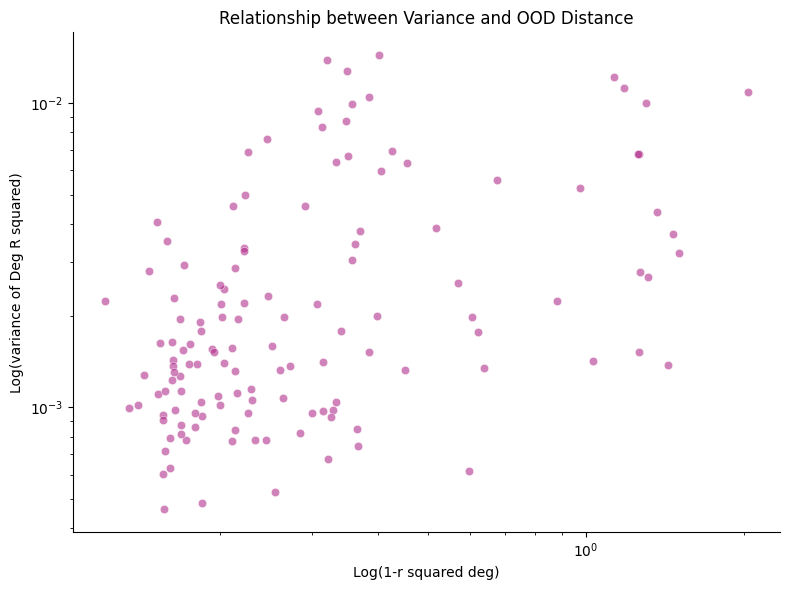

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the figure size
plt.figure(figsize=(8, 6))

# Create the scatterplot
sns.scatterplot(
    data=df, 
    x='one_minus_mean_deg_r_sq_per_cell_type', 
    y='mean_var_mean_deg_gex_per_cell_type',
    color="#B12F8C",
    alpha=0.6,
    edgecolor="w"
)

# Apply log scales to both axes
plt.xscale('log')
plt.yscale('log')

# Clean up labels and title
plt.xlabel('Log(1-r squared deg)')
plt.ylabel('Log(variance of Deg R squared)')
plt.title('Relationship between Variance and OOD Distance')

# Remove unnecessary chart borders
sns.despine()

plt.tight_layout()
plt.savefig("calibration_deg.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

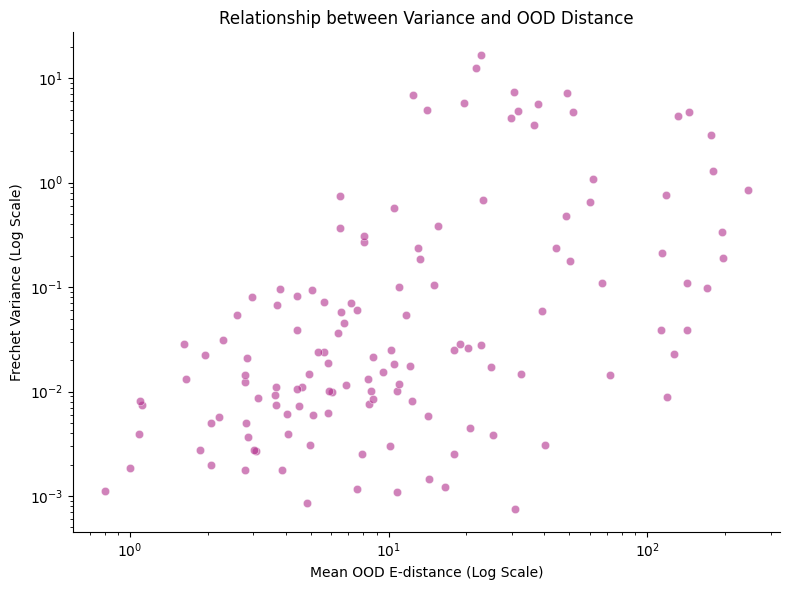

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the figure size
plt.figure(figsize=(8, 6))

# Create the scatterplot
sns.scatterplot(
    data=df, 
    x='mean_ood_e_distance',
    y='frechet_variance', 
    color="#B12F8C",
    alpha=0.6,
    edgecolor="w"
)

# Apply log scales to both axes
plt.xscale('log')
plt.yscale('log')

# Clean up labels and title
plt.xlabel('Mean OOD E-distance (Log Scale)')
plt.ylabel('Frechet Variance (Log Scale)')
plt.title('Relationship between Variance and OOD Distance')

# Remove unnecessary chart borders
sns.despine()

plt.tight_layout()
plt.savefig("calibration_frechet.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
df_res

,spearman_frechet,pearson_frechet,spearman_deg,pearson_deg,mean_r_sq_per_cell_type,mean_ood_e_distance
Donor10,0.081818,-0.091283,0.427273,0.079363,0.734661,19.053286
Donor11,0.427273,0.095485,0.545455,0.320770,0.539982,33.146526
Donor12,0.590909,0.474199,0.400000,0.554371,0.552730,33.749868
Donor1,0.545455,0.062018,0.309091,0.174327,0.631618,22.516433
Donor2,0.772727,0.138475,0.372727,0.235214,0.619312,28.480466
Donor3,0.309091,0.291268,0.045455,0.098139,0.761442,7.112626
Donor4,0.281818,0.022390,0.409091,0.132734,0.734617,20.547200
Donor5,0.409091,0.271594,0.381818,0.619598,0.503196,35.700844
Donor6,0.527273,0.136192,0.354545,0.256972,0.654328,23.638436
Donor7,0.590909,0.091803,0.718182,0.587133,0.530629,33.202811


In [14]:
df_res["donor"] = df_res.index

In [15]:
df_res.to_csv(os.path.join(file_dir, "df_calibration.csv"))

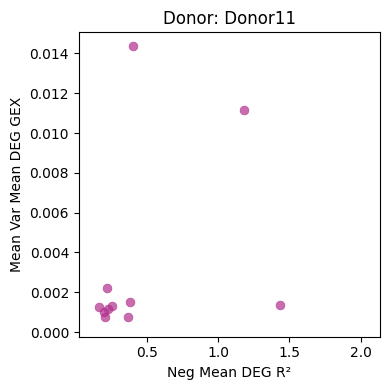

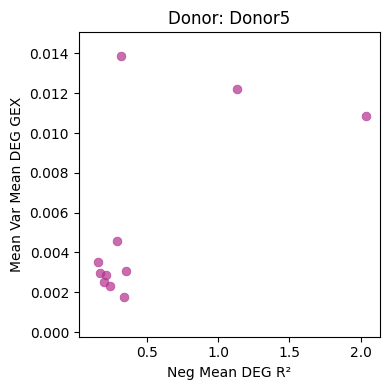

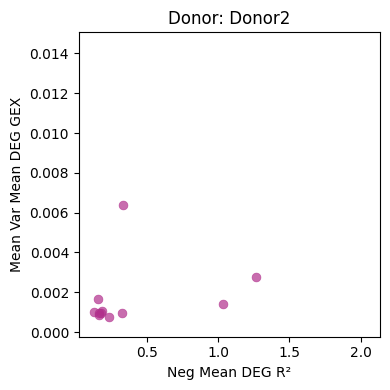

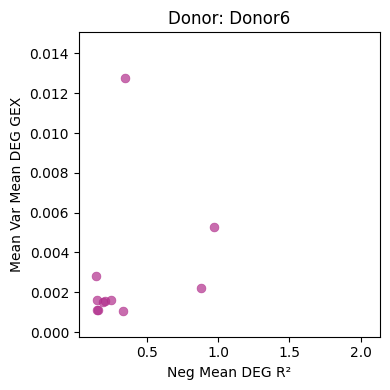

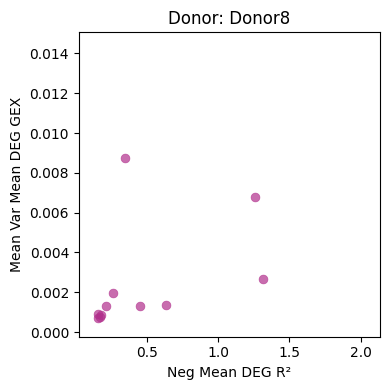

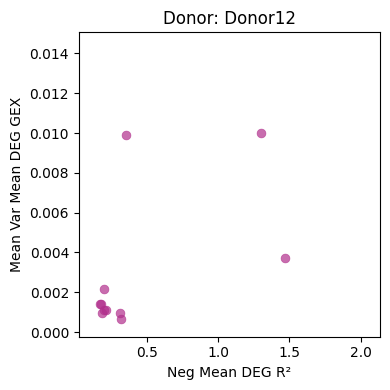

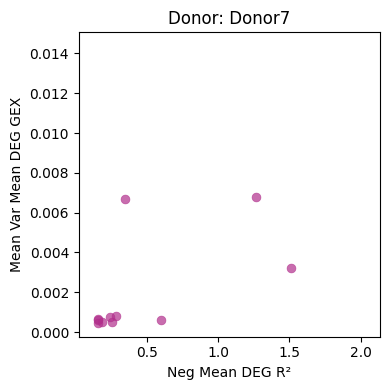

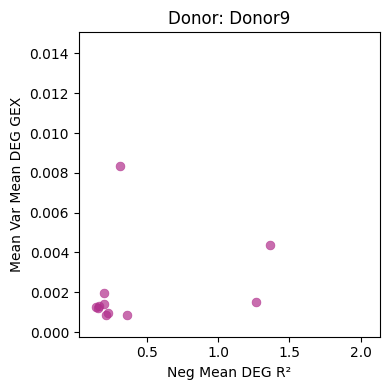

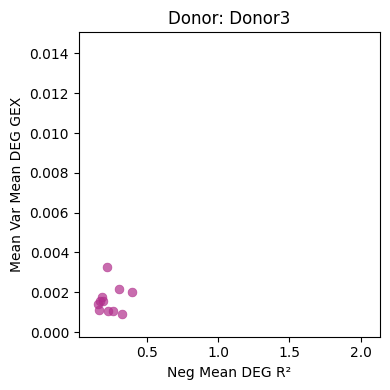

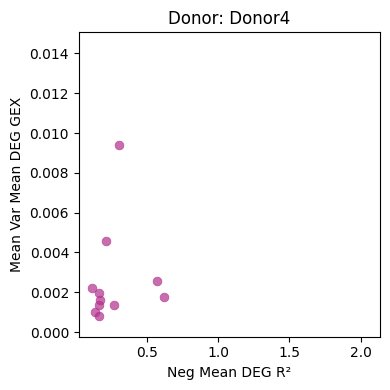

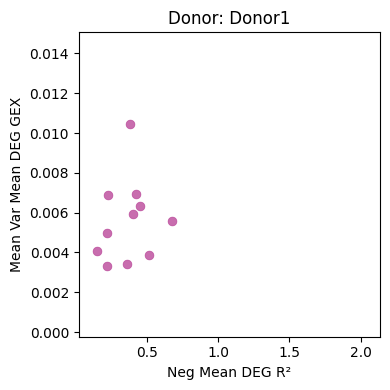

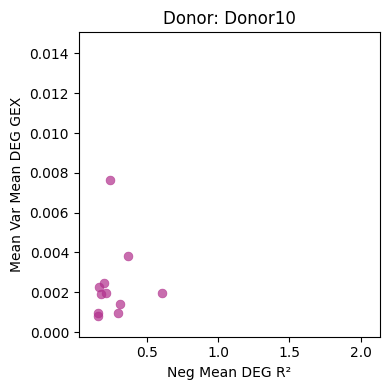

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

output_dir = "/lustre/groups/ml01/workspace/ot_perturbation/figures/pbmc/cellflow_stochastic"
os.makedirs(output_dir, exist_ok=True)

# 1. Define specific donor order
donor_order = [
    'Donor11', 'Donor5', 'Donor2', 'Donor6', 'Donor8', 'Donor12',
    'Donor7', 'Donor9', 'Donor3', 'Donor4', 'Donor1', 'Donor10'
]

x_col = "one_minus_mean_deg_r_sq_per_cell_type"
y_col = "mean_var_mean_deg_gex_per_cell_type"

# 2. Compute global limits with a 5% buffer
def get_buffered_limits(data_series, buffer=0.05):
    dmin, dmax = data_series.min(), data_series.max()
    drange = dmax - dmin
    return dmin - (drange * buffer), dmax + (drange * buffer)

xmin, xmax = get_buffered_limits(df[x_col])
ymin, ymax = get_buffered_limits(df[y_col])

# 3. Iterate and Plot
for donor in donor_order:
    if donor not in df["donor"].values:
        continue
        
    df_tmp = df[df["donor"] == donor].copy()
    
    plt.figure(figsize=(4, 4))

    sns.scatterplot(
        data=df_tmp,
        x=x_col,
        y=y_col,
        alpha=0.7,
        edgecolor=None,
        s=40,
        color="#B12F8C"
    )

    plt.title(f"Donor: {donor}", fontsize=12)
    plt.xlabel("Neg Mean DEG R²")
    plt.ylabel("Mean Var Mean DEG GEX")
    
    # Apply the buffered limits
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)

    plt.tight_layout()

    # 4. Save and Show
    save_path = os.path.join(output_dir, f"{donor}_scatter_plot.pdf")
    plt.savefig(save_path, format="pdf", bbox_inches='tight')
    
    plt.show()
    plt.close()

In [17]:
df_res = []
for cyto in df["cytokine"].unique():
    donor_dict = {}
    df_d = df[df["cytokine"]==cyto]
    donor_dict["spearman_frechet"] = df_d[["frechet_variance", "mean_ood_e_distance"]].corr(method="spearman").iloc[0,1]
    donor_dict["pearson_frechet"] = df_d[["frechet_variance", "mean_ood_e_distance"]].corr(method="pearson").iloc[0,1]
    donor_dict["spearman_deg"] = df_d[["one_minus_mean_deg_r_sq_per_cell_type", "mean_var_mean_deg_gex_per_cell_type"]].corr(method="spearman").iloc[0,1]
    donor_dict["pearson_deg"] = df_d[["one_minus_mean_deg_r_sq_per_cell_type", "mean_var_mean_deg_gex_per_cell_type"]].corr(method="pearson").iloc[0,1]
    donor_dict["mean_deg_r_sq_per_cell_type"] = df_d["mean_deg_r_sq_per_cell_type"].mean()
    donor_dict["mean_ood_e_distance"] = df_d["ood_e_distance_0"].mean()
    df_res.append(pd.DataFrame.from_dict(donor_dict, orient="index", columns=[cyto]).T)

df_res2 = pd.concat(df_res)


In [18]:
df_res2

,spearman_frechet,pearson_frechet,spearman_deg,pearson_deg,mean_deg_r_sq_per_cell_type,mean_ood_e_distance
4-1BBL,0.503497,0.246731,0.300699,0.607141,0.827927,4.342165
IFN-epsilon,-0.083916,-0.031804,0.314685,0.443230,0.668611,38.134791
IL-15,0.062937,0.629095,0.237762,0.567832,-0.083741,87.832601
OX40L,0.454545,-0.063603,-0.097902,-0.173271,0.777578,7.753308
Noggin,0.195804,0.202874,0.377622,0.782377,0.756498,11.876193
APRIL,0.076923,0.159052,0.230769,-0.081332,0.796927,7.299953
OSM,0.314685,0.392274,0.706294,0.765378,0.823399,5.791772
ADSF,0.412587,0.874834,-0.076923,0.615677,0.799283,7.765236
BAFF,0.713287,0.178963,0.300699,0.373928,0.752128,6.698170
IFN-beta,0.090909,0.194001,0.300699,0.410873,0.020851,108.646929


In [19]:
df_res2["cytokine"] = df_res2.index

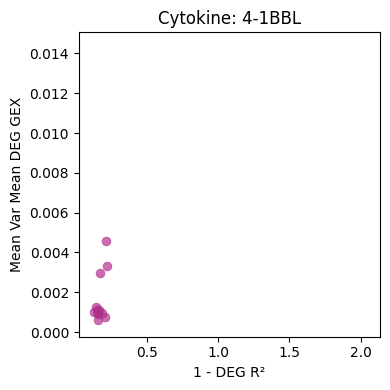

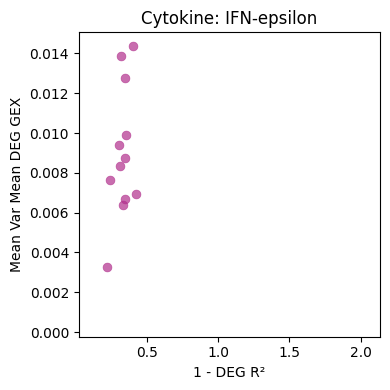

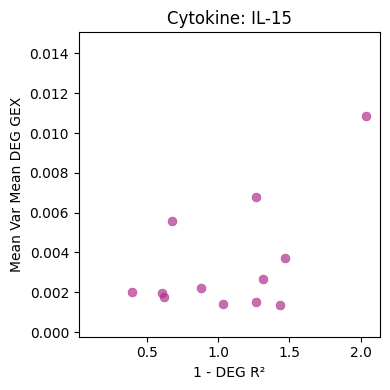

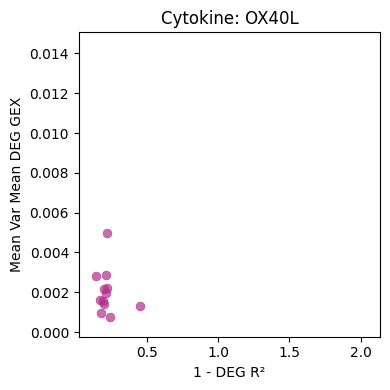

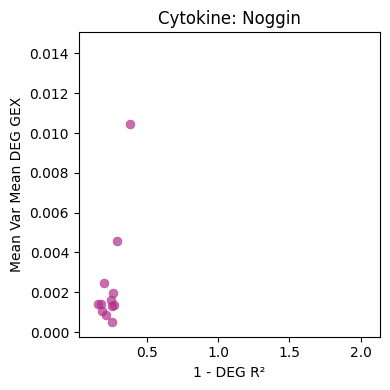

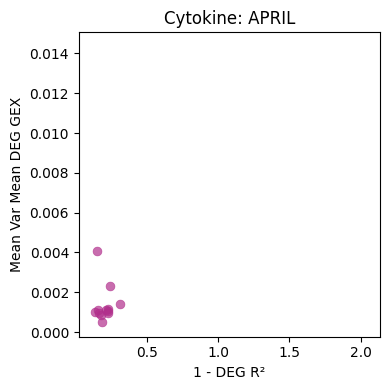

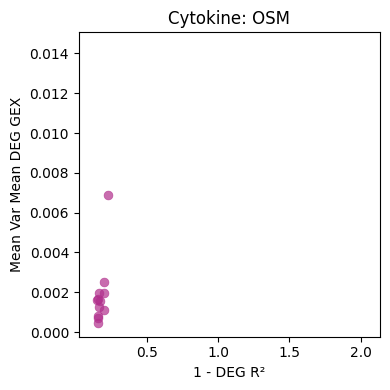

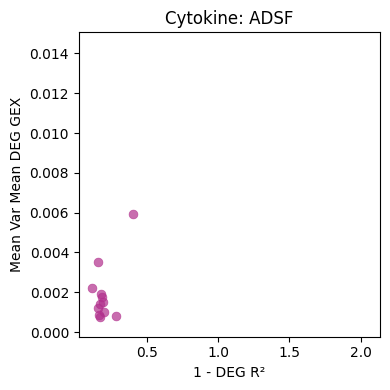

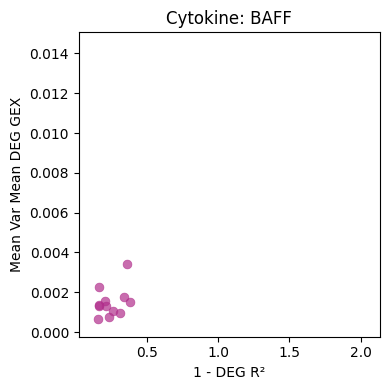

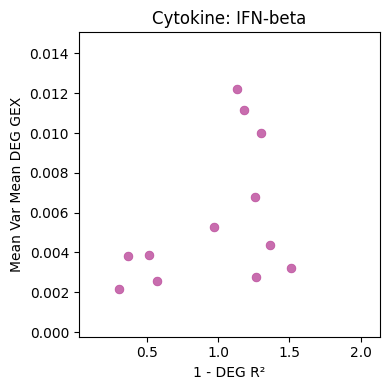

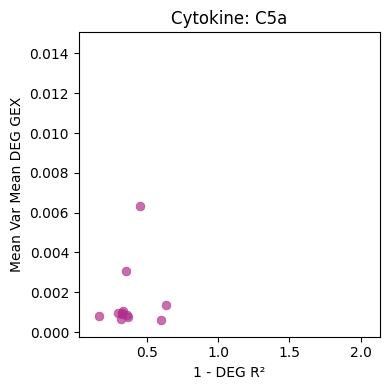

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os


# 1. Define specific donor order
cytokines = df["cytokine"].unique()

x_col = "one_minus_mean_deg_r_sq_per_cell_type"
y_col = "mean_var_mean_deg_gex_per_cell_type"

# 2. Compute global limits with a 5% buffer
def get_buffered_limits(data_series, buffer=0.05):
    dmin, dmax = data_series.min(), data_series.max()
    drange = dmax - dmin
    return dmin - (drange * buffer), dmax + (drange * buffer)

xmin, xmax = get_buffered_limits(df[x_col])
ymin, ymax = get_buffered_limits(df[y_col])

# 3. Iterate and Plot
for cyto in cytokines:

    df_tmp = df[df["cytokine"] == cyto].copy()
    
    plt.figure(figsize=(4, 4))

    sns.scatterplot(
        data=df_tmp,
        x=x_col,
        y=y_col,
        alpha=0.7,
        edgecolor=None,
        s=40,
        color="#B12F8C"
    )

    plt.title(f"Cytokine: {cyto}", fontsize=12)
    plt.xlabel("1 - DEG R²")
    plt.ylabel("Mean Var Mean DEG GEX")
    
    # Apply the buffered limits
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)

    plt.tight_layout()
    
    # 4. Save and Show
    save_path = os.path.join(output_dir, f"{cyto}_scatter_plot.pdf")
    plt.savefig(save_path, format="pdf", bbox_inches='tight')
    
    plt.show()
    plt.close()